In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Make `src/autocall` importable when the notebook is launched from the repo root.
ROOT = Path.cwd()
if (ROOT / "src").is_dir():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").is_dir():
    sys.path.insert(0, str(ROOT.parent / "src"))

import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql

from autocall.market_data import MarketData
from autocall.vol.implied_surface import build_black_variance_surface
from autocall.vol.svi import fit_svi_surface, svi_to_black_variance_surface
from autocall.process import build_process_array
from autocall.time_grid import build_time_grid, grid_indices_of_obs_dates
from autocall.path_generator import PathGenerator

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.5)

eval_date = ql.Date(15, 5, 2026)
ql.Settings.instance().evaluationDate = eval_date
calendar = ql.TARGET()
day_counter = ql.Actual365Fixed()


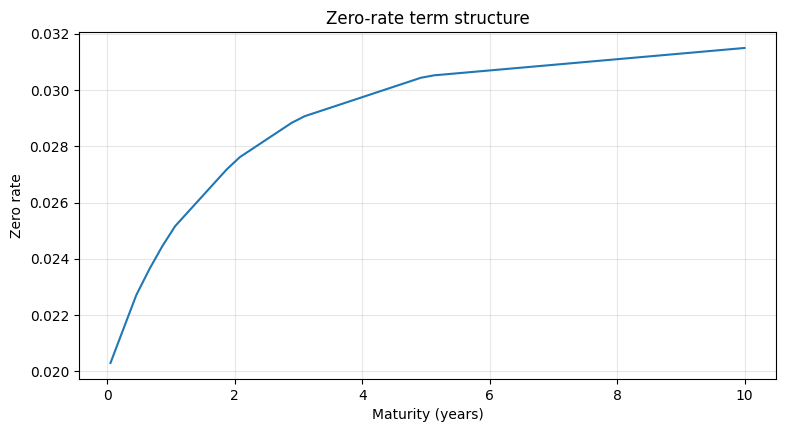

In [2]:
zero_dates = [
    eval_date,
    eval_date + ql.Period(1, ql.Months),
    eval_date + ql.Period(3, ql.Months),
    eval_date + ql.Period(6, ql.Months),
    eval_date + ql.Period(1, ql.Years),
    eval_date + ql.Period(2, ql.Years),
    eval_date + ql.Period(3, ql.Years),
    eval_date + ql.Period(5, ql.Years),
    eval_date + ql.Period(10, ql.Years),
]
zero_rates = [0.0200, 0.0205, 0.0215, 0.0230, 0.0250, 0.0275, 0.0290, 0.0305, 0.0315]

zero_curve = ql.ZeroCurve(zero_dates, zero_rates, day_counter, calendar)
zero_curve.enableExtrapolation()
discount_handle = ql.YieldTermStructureHandle(zero_curve)

# Quick look at the curve
ts = np.linspace(0.05, 10.0, 50)
zs = [zero_curve.zeroRate(t, ql.Continuous).rate() for t in ts]
plt.plot(ts, zs)
plt.title("Zero-rate term structure")
plt.xlabel("Maturity (years)"); plt.ylabel("Zero rate")
plt.grid(alpha=0.3); plt.show()

In [3]:
asset_names = ["IDX_A", "IDX_B", "IDX_C"]
spots_initial = [5_500.0, 4_800.0, 38_000.0]   # realistic index levels

div_term_pillars = [
    eval_date,
    eval_date + ql.Period(1, ql.Years),
    eval_date + ql.Period(3, ql.Years),
    eval_date + ql.Period(5, ql.Years),
]
div_yield_by_asset = {
    "IDX_A": [0.0090, 0.0105, 0.0115, 0.0120],
    "IDX_B": [0.0190, 0.0205, 0.0215, 0.0220],
    "IDX_C": [0.0330, 0.0345, 0.0355, 0.0360],
}
dividend_handles = []
for name in asset_names:
    curve = ql.ZeroCurve(div_term_pillars, div_yield_by_asset[name], day_counter, calendar)
    curve.enableExtrapolation()
    dividend_handles.append(ql.YieldTermStructureHandle(curve))

for name, h in zip(asset_names, dividend_handles):
    qs = [h.zeroRate(t, ql.Continuous).rate() for t in (0.5, 1.0, 2.0, 3.0, 5.0)]
    print(f"{name:>6s} fwd div yield @ 0.5/1/2/3/5y: {np.round(qs, 4)}")
    

 IDX_A fwd div yield @ 0.5/1/2/3/5y: [0.0097 0.0105 0.011  0.0115 0.012 ]
 IDX_B fwd div yield @ 0.5/1/2/3/5y: [0.0197 0.0205 0.021  0.0215 0.022 ]
 IDX_C fwd div yield @ 0.5/1/2/3/5y: [0.0338 0.0345 0.035  0.0355 0.036 ]


In [4]:
correlation = np.array([
    [1.00, 0.75, 0.55],
    [0.75, 1.00, 0.60],
    [0.55, 0.60, 1.00],
])
# Verify PSD ourselves to be sure.
print("eigenvalues:", np.linalg.eigvalsh(correlation))

eigenvalues: [0.246  0.4833 2.2707]


In [5]:
spot_quotes = [ql.SimpleQuote(s) for s in spots_initial]


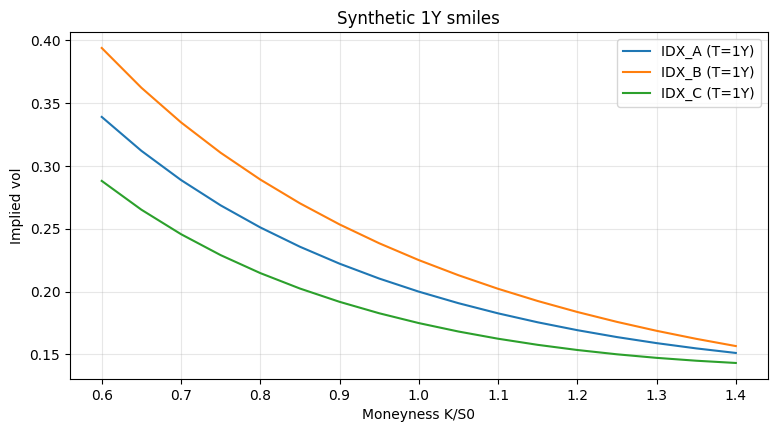

In [6]:
expiries = [eval_date + ql.Period(i, ql.Months) for i in (3, 6, 12, 18, 24, 30, 36)]
times = np.array([day_counter.yearFraction(eval_date, d) for d in expiries])

def synthetic_vol_matrix(spot: float, atm_short: float, atm_long: float,
                         skew_short: float, skew_long: float,
                         strikes: np.ndarray, expiries: list[ql.Date]) -> pd.DataFrame:
    times = np.array([day_counter.yearFraction(eval_date, d) for d in expiries])
    # ATM linearly grows from short to long maturity (typical contango)
    atm = atm_short + (atm_long - atm_short) * (times - times[0]) / (times[-1] - times[0])
    skew = skew_short + (skew_long - skew_short) * (times - times[0]) / (times[-1] - times[0])
    convexity = 0.12 + 0.02 * times          # convexity ~ 0.12-0.20
    vol = np.zeros((len(strikes), len(expiries)))
    for j, T in enumerate(times):
        # forward including the per-asset div yield
        # (we use spot * exp((r - q) * T); but for shape we just need a sensible forward)
        r_T = zero_curve.zeroRate(T, ql.Continuous).rate()
        q_T = 0.02  # average div used only to centre log-moneyness
        F = spot * math.exp((r_T - q_T) * T)
        m = np.log(strikes / F)
        vol[:, j] = atm[j] * (1.0 - skew[j] * m) + convexity[j] * m**2
        vol[:, j] = np.clip(vol[:, j], 0.05, 1.5)
    return pd.DataFrame(vol, index=strikes, columns=expiries)

# Per-asset strike grids around respective spots
strike_grids = {
    "IDX_A": np.linspace(0.60, 1.40, 17) * spots_initial[0],
    "IDX_B": np.linspace(0.60, 1.40, 17) * spots_initial[1],
    "IDX_C": np.linspace(0.60, 1.40, 17) * spots_initial[2],
}

vol_matrices = {
    "IDX_A": synthetic_vol_matrix(spots_initial[0], 0.18, 0.22, 1.2, 0.7,
                                   strike_grids["IDX_A"], expiries),
    "IDX_B": synthetic_vol_matrix(spots_initial[1], 0.20, 0.25, 1.4, 0.8,
                                   strike_grids["IDX_B"], expiries),
    "IDX_C": synthetic_vol_matrix(spots_initial[2], 0.16, 0.19, 1.0, 0.6,
                                   strike_grids["IDX_C"], expiries),
}

# Visual check: smile slices at 1Y per asset
fig, ax = plt.subplots(figsize=(9, 4.5))
for name in asset_names:
    grid = strike_grids[name]
    mness = grid / spots_initial[asset_names.index(name)]
    ax.plot(mness, vol_matrices[name].iloc[:, 3], label=f"{name} (T=1Y)")
ax.set_xlabel("Moneyness K/S0"); ax.set_ylabel("Implied vol")
ax.set_title("Synthetic 1Y smiles"); ax.grid(alpha=0.3); ax.legend()
plt.show()


In [7]:
strike_grids['IDX_A']

array([3300., 3575., 3850., 4125., 4400., 4675., 4950., 5225., 5500.,
       5775., 6050., 6325., 6600., 6875., 7150., 7425., 7700.])

In [8]:
vol_qlmatrix = ql.Matrix(len(strike_grids['IDX_A']), len(expiries))
for i, _ in enumerate(strike_grids['IDX_A']):
    for j, _ in enumerate(expiries):
        vol_qlmatrix[i][j] = float(vol_matrices['IDX_A'].iloc[i, j])
        
print(vol_qlmatrix)


| 0.323097 0.326418 0.332892 0.339096 0.344982 0.350222 0.354916 |
| 0.296376 0.299614 0.305971 0.312131 0.318033 0.323377 0.32824 |
| 0.273065 0.276284 0.282646 0.28888 0.29491 0.300467 0.305598 |
| 0.252597 0.255849 0.262313 0.268715 0.274964 0.280817 0.286298 |
| 0.234528 0.237854 0.2445 0.251146 0.257684 0.263902 0.269794 |
| 0.218504 0.221937 0.228829 0.235781 0.242668 0.249305 0.255658 |
| 0.204238 0.207806 0.214996 0.222305 0.229587 0.236687 0.243543 |
| 0.191495 0.195222 0.202753 0.21046 0.218176 0.225775 0.233165 |
| 0.180082 0.183986 0.191895 0.200034 0.208216 0.216342 0.224293 |
| 0.169836 0.173934 0.182251 0.19085 0.199523 0.2082 0.216733 |
| 0.160622 0.164926 0.173676 0.182758 0.191944 0.201191 0.210324 |
| 0.152322 0.156845 0.166049 0.175634 0.18535 0.195182 0.204927 |
| 0.144839 0.149589 0.159264 0.169368 0.179629 0.190059 0.200427 |
| 0.138088 0.143073 0.153233 0.163869 0.174686 0.185724 0.196723 |
| 0.131993 0.13722 0.147879 0.159056 0.17044 0.182093 0.19373 |
| 0.1264

In [9]:
vol = ql.BlackVarianceSurface(
    eval_date, 
    calendar, 
    expiries, 
    strike_grids['IDX_A'], 
    vol_qlmatrix, 
    day_counter
)

vol_handle = ql.BlackVolTermStructureHandle(vol)
spot = ql.QuoteHandle(spot_quotes[0])

# local_vol = ql.LocalVolSurface(
#     vol_handle,
#     discount_handle,
#     dividend_handles[0],
#     spot
# )


In [ ]:
x = np.linspace(3000, 7000, 4000)
lv = []

for _ in x:
    try:
        lv.append(local_vol.localVol(ql.Date(10, 10, 2026), _))
    except RuntimeError:
        lv.append(0)

plt.plot(x, lv)        

In [10]:
process = ql.GeneralizedBlackScholesProcess(
    spot, 
    discount_handle, 
    dividend_handles[0],
    ql.BlackVolTermStructureHandle(vol),
    # ql.LocalVolTermStructureHandle(local_vol)
)

years = 10
months = 12
steps = years * months


In [11]:
uniform = ql.UniformLowDiscrepancySequenceGenerator(steps)
gaussian = ql.GaussianLowDiscrepancySequenceGenerator(uniform)
generator = ql.GaussianSobolPathGenerator(
    process, 
    years,
    steps,
    gaussian,
    True
)


In [12]:
generator.next()

RuntimeError: negative local vol^2 at strike 4115.25 and time 3.66667; the black vol surface is not smooth enough